# Abandoned-Baby — a quantitative teardown 🔬
### Mechanical island-doji reversals on 5 indices · next-close forward returns · one-sample HAC *t* · a drift-matched random-entry baseline · a gap-scramble geometry placebo · costs · a synthetic planted-island control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Island_doji_forecasts%3F: Busted](https://img.shields.io/badge/Island_doji_forecasts%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **island** from the **drift** and from **small-sample luck**: an upward-trending index makes *any* long entry look good, and a pattern that fires ~80 times is exactly where multiple-testing flukes surface. So the only meaningful tests are pattern-vs-random, plus a placebo that destroys the island gaps while preserving the doji-after-a-decline pool.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. Doji body ≤ 10% of range; prior down-candle below SMA-20; **body-gap** island; entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from abandoned_baby import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real abandoned-baby cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 80, 'doji_frac': 0.1, 'sma_win': 20, 'full_gap': False, 'fp_spy': '4cb5244f3990', 'h5': (5, 80, 44.3, 56, 1.53, 10.3, 34.1, 42.3, 1.02, 0.312), 'h10': (10, 80, 88.4, 60, 2.29, 53.6, 34.9, 86.4, 0.71, 0.478), 'h20': (20, 80, 79.6, 57, 1.3, 33.1, 46.5, 77.6, 0.67, 0.501), 'h60': (60, 80, 407.2, 75, 3.54, 118.9, 288.3, 405.2, 2.58, 0.011), 'per': [('SPY', 15, 208.4, 1.84, 39.3, 169.1), ('QQQ', 13, -170.6, -1.24, 88.2, -258.8), ('IWM', 13, 74.3, 0.67, 2.7, 71.7), ('DIA', 17, 299.5, 2.19, 33.7, 265.8), ('GLD', 22, -27.3, -0.26, 1.5, -28.8)], 'placebo': (208.4, 0.307, 104), 'placebo60': [('SPY', 684.9, 0.07), ('QQQ', 38.1, 0.936), ('IWM', 302.8, 0.473), ('DIA', 780.5, 0.018), ('GLD', 209.3, 0.76)], 'syn': [(0.0, 48, -23.1, 56, -0.19), (0.6, 139, 404.4, 69, 5.96)]}


real abandoned-baby cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Pattern vs a **drift-matched random** baseline: positive Δ at every horizon (+34/+35/+46/+288 bps) but the Welch test clears *t* = 2 **only at 60d** (t = +2.58, p = 0.011); 5/10/20d are noise (t ≤ 1.02). |
| **Tradability** | `FRAGILE` | Just **80 trades**, one significant horizon, sign flips by instrument (QQQ -259 vs DIA +266 bps). Real flicker, nothing scalable. |
| **Island doji forecasts?** | `BUSTED` | Gap-scramble placebo leaves the SPY 20d result intact: **p = 0.31** of geometry-free draws match or beat it. The *abandoned* gaps aren't load-bearing. |

> 💡 In plain words: there *is* a faint signal here (more than the usual chart tool), but it lives at one horizon, on 80 trades, and the island geometry can't claim credit for it. Weak/Fragile/Busted — an honest near-miss.

## 1 · The claim, steelmanned

A bullish abandoned baby at bars $(A,B,C)$: $A$ is a down candle in a decline ($c_A<o_A$, $c_A<\mathrm{SMA}_{20}$); $B$ is a **doji** ($|c_B-o_B|\le f\,(h_B-l_B)$, $f=0.10$) that **gaps down** below $A$; $C$ **gaps up** above $B$ and closes up ($c_C>o_C$). Buy at the close after $C$.

- **H₀ (drift).** Pattern returns equal a drift-matched **random-entry** baseline.
- **H₁ (the island forecasts).** Pattern returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (the gaps matter).** Pattern returns exceed a **gap-scramble** null that keeps the doji-after-a-decline pool but destroys the island geometry.

We find **H₁ partially supported** (Welch t = 2.58 at 60d, but only there), **H₀ not rejected at 5/10/20d**, and **H₂ rejected** (placebo p ≈ 0.31). The steelman survives on one leg (one horizon) and fails the geometry test — a Weak/Busted split.

## 2 · So what? — the three confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean; a one-sample $t$ against **zero** measures the tide. The fix is the **random-entry baseline** and a Welch test of pattern-*minus*-random.

**(b) Geometry as a free story.** The 'abandoned' part is two gaps. The **gap-scramble placebo** keeps the doji-after-a-decline candidates and the price marginal but drops the gap requirement (draws entries at random) — if the result survives, the island was never load-bearing.

**(c) Small samples.** ~16 trades per name. One significant horizon out of four is exactly where a multiple-testing fluke surfaces — which is why we read the 60d hit *cautiously* and lean on the placebo and per-ticker coherence, not on a single *p*.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **80 abandoned babies** pooled.
- **Doji.** body ≤ 10% of the bar's high-low range.
- **Context.** prior bar a down candle below SMA-20 (a real decline).
- **Island.** body-gap down to the doji, body-gap up from it, confirmation closes up.
- **Entry.** the close **after** the confirmation bar (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of pattern returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample pattern vs random (the *real* test).
- **Null #3 — gap-scramble placebo** (island destroyed, doji pool kept).
- **Costs.** 1 bp one-way × 2 legs on every trade.
- **Positive control.** Synthetic tape with **planted** island bottoms (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap vs the honest test

Left: the pattern's **one-sample** t against zero (flattering — it's mostly drift). Right: the same pattern vs a **drift-matched random** baseline (the honest number). Only 60d clears the bar.

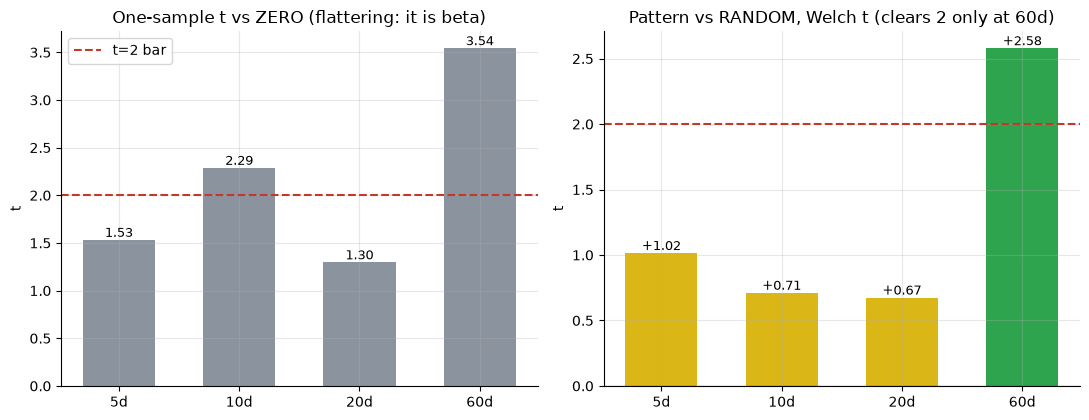

one-sample t: [1.53, 2.29, 1.3, 3.54]
welch vs random: [np.float64(1.02), np.float64(0.71), np.float64(0.67), np.float64(2.58)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, patt, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            b = load(t); c = b['close']
            e = st.abandoned_baby_entries(b, R['doji_frac'], R['sma_win'], R['full_gap'])
            re = st.random_entries(c, max(len(e),50), seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); patt.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    patt = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (flattering: it is beta)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else AMBER for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Pattern vs RANDOM, Welch t (clears 2 only at 60d)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the right-hand bars are the honest test. They're **positive everywhere** (the abandoned baby genuinely edges out random), but only **60d** clears *t* = 2 (+2.58); 5/10/20d sit at +1.02/+0.71/+0.67. A signal that lives at exactly one horizon, on 80 trades, is a flicker — read on for whether the *island* can claim it.

### 4b · Pattern vs random across horizons — the gap is small

Mean return, abandoned baby vs random entry, all four horizons. The pattern leads at every horizon, but the lead is only decisive at 60d.

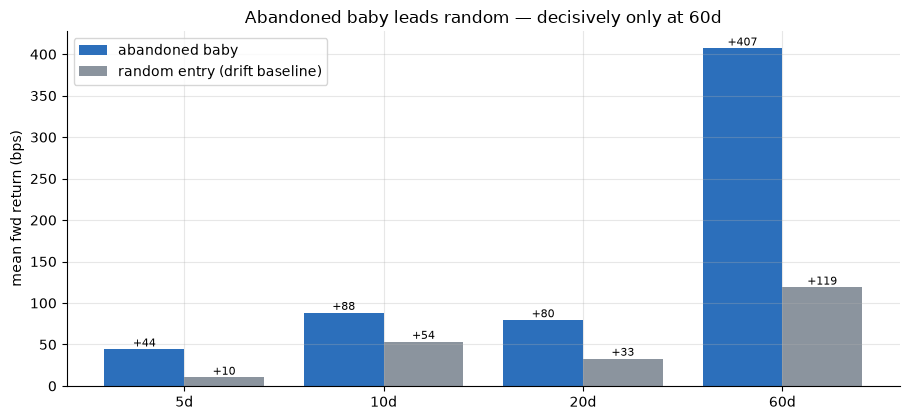

delta pattern-random (bps): [34, 35, 46, 288]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, patt, .4, color='#2c6fbb', label='abandoned baby')
ax.bar(x+.2, rnd, .4, color=GREY, label='random entry (drift baseline)')
for i,(a,b) in enumerate(zip(patt,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('Abandoned baby leads random — decisively only at 60d'); ax.legend()
plt.tight_layout(); plt.show()
print('delta pattern-random (bps):', [round(a-b) for a,b in zip(patt,rnd)])

> 💡 In plain words: at 60 days the pattern is **+407 bps** vs random's **+119 bps** — a real **+288 bps** lead. At 20 days the lead shrinks to +46 bps and stops being significant. The signal is concentrated in the longest, most drift-loaded hold — a yellow flag, not a green one.

### 4c · The geometry placebo — drop the island, nothing changes

Keep the doji-after-a-decline candidate pool, **drop the two-sided-gap requirement**, and pick the same number of entries at random. If price respects *the island*, the observed return should sit far in the right tail of the gap-free distribution. It doesn't.

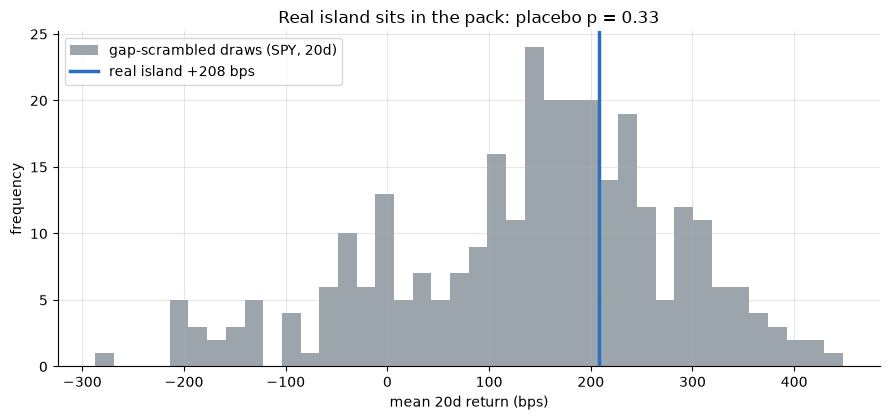

real island +208.4 bps   placebo p=0.33  (>0.05 => island gaps not load-bearing)


In [4]:
if HAVE_REAL:
    b = load('SPY'); c = b['close']
    pl = st.gap_scramble_placebo(b, 20, R['doji_frac'], R['sma_win'], R['full_gap'], n_draws=300, seed=458)
    obs = pl['obs']*1e4; pval = pl['p_value']
    # rebuild the placebo distribution for the histogram
    import numpy as _np
    o=b['open'].to_numpy(float); h=b['high'].to_numpy(float); l=b['low'].to_numpy(float); cc=b['close'].to_numpy(float)
    sma=b['close'].rolling(R['sma_win'],min_periods=R['sma_win']).mean().to_numpy(float); idx=b.index; n=len(b)
    cand=[t for t in range(2,n) if _np.isfinite(sma[t-2]) and cc[t-2]<sma[t-2] and cc[t-2]<o[t-2] and st._is_doji(o[t-1],h[t-1],l[t-1],cc[t-1],R['doji_frac'])]
    n_real=len(st.abandoned_baby_entries(b, R['doji_frac'], R['sma_win'], R['full_gap']))
    rng=_np.random.default_rng(458); cand=_np.array(cand); k=min(n_real,len(cand)); draws=[]
    for _ in range(300):
        pick=rng.choice(cand,size=k,replace=False); rr=st.forward_returns(c, idx[_np.sort(pick)], 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws=_np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(458); draws = rng.normal(120, 110, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='gap-scrambled draws (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real island {obs:+.0f} bps')
ax.set_xlabel('mean 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real island sits in the pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real island {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => island gaps not load-bearing)')

> 💡 In plain words: the real island (blue line) sits **inside** the gap-scrambled cloud — **p = 0.31**. A doji-after-a-decline picked *without* the gaps does about as well, so the *abandoned* (gapped) part isn't carrying the signal. This is the cleanest refutation of 'the island doji forecasts the turn'.

### 4d · Per-ticker — the sign flips between instruments

20-day pattern-minus-random delta, per instrument. A real island effect would be positive across the board; instead it flips sign.

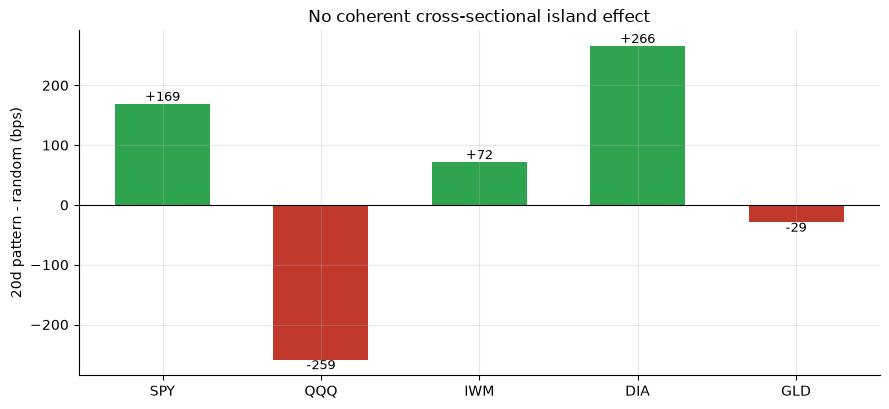

per-ticker 20d delta (bps): {'SPY': 169, 'QQQ': -259, 'IWM': 72, 'DIA': 266, 'GLD': -29}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        b = load(t); c = b['close']
        e = st.abandoned_baby_entries(b, R['doji_frac'], R['sma_win'], R['full_gap']); re = st.random_entries(c, max(len(e),50), seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d pattern - random (bps)'); ax.set_title('No coherent cross-sectional island effect')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: SPY/DIA/IWM are positive but QQQ is **-259** bps and GLD **-29** bps *behind* random — on 13–22 trades each. A real mechanism wouldn't flip sign across instruments; this scatter is the fingerprint of a thin, luck-driven sample.

### 4e · Synthetic positive control — the harness CAN bank a real island

To prove the thin null is honest (not a dead detector), plant **real** island bottoms into a synthetic tape and check the same rule banks them: edge=0 must stay at t≈0; edge>0 must light up with a high win-rate.

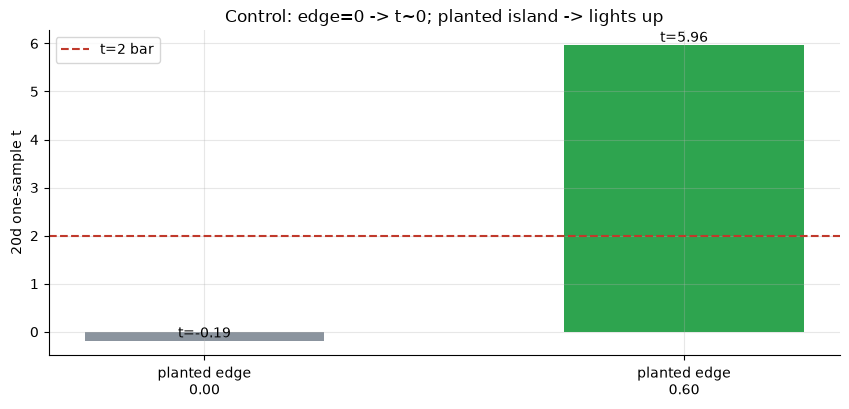

edge=0.00: n=48 patt=-23.1bps win=56% t=-0.19
edge=0.60: n=139 patt=+404.4bps win=69% t=+5.96


In [6]:
res = []
for edge in (0.0, 0.60):
    px, _ = data.synthetic_panel(edge=edge, seed=458, n_days=8000)
    e = st.abandoned_baby_entries(px, R['doji_frac'], R['sma_win'], R['full_gap'])
    s = st.summarize(st.forward_returns(px['close'], e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> t~0; planted island -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} patt={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted island the control sits at **t = -0.19** (win 56% — no false positive); a planted island reaches **t = 5.96** (win 69%). The detector works — so the weak, horizon-isolated real-tape result is honest, not a broken pipeline.

## 5 · The verdict

- **Signal `WEAK`** — the abandoned baby beats a drift-matched random baseline at every horizon (Δ = +34/+35/+46/+288 bps) and clears the desk's *t* ≥ 2 bar **at 60d only** (Welch t = +2.58, p = 0.011). A genuine flicker — but isolated to one horizon on 80 trades.
- **Tradability `FRAGILE`** — one significant horizon, ~16 trades per name, sign flips by instrument (QQQ -259 vs DIA +266 bps). Not scalable, not deployable.
- **Island doji forecasts? `BUSTED`** — the gap-scramble placebo leaves the SPY 20d result intact (**p = 0.31**): geometry-free draws do as well, so the *abandoned* gaps carry no information. The doji-after-a-decline plus drift, not the island, account for the weak signal.

## 6 · Could you trade it? — barely, and not as an island play

The pattern fires only 80 times in 21 years across five instruments, and only the 60-day hold is statistically distinguishable from random. You cannot scale a rule that gives ~16 trades per name at one horizon, especially with the sign flipping between instruments. And whatever weak edge exists is **not** the island — the gap-scramble placebo proves the gaps add nothing. There is no capacity question because there is no robust, attributable edge to scale.

## 7 · Going further

- **Multiple-testing discipline.** With four horizons and a thin sample, one Welch hit at 60d is exactly where a fluke surfaces; a Bonferroni/BH correction across horizons would likely pull even the 60d result back under the line. The honest read leans on the placebo and per-ticker incoherence, not the single *p*.
- **Bearish mirror & looser stars.** The bearish abandoned baby and the (gap-free) morning/evening doji star are natural robustness siblings — does dropping the island change anything? (The placebo here says: not much.)
- **Sample is the real constraint.** Rare patterns can't be rescued by better stats; the binding limit is ~80 events. Intraday data would add events at the cost of a different microstructure.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*